Считаем метрики RMSE и MASE по месячным прогнозам на реальных данных.
Загружаем данные прогнозов forecasts_catboost_monthly.csv и реальных данных actual_monthly_payments.csv, которые генерируются и дополняются после прогона production версии скрипта.

In [ ]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", None)

In [ ]:
def mase(y_true, y_pred, y_train, seasonality=12): # seasonality 12 для месячных
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_train = np.asarray(y_train)
    
    # проверка на достаточность данных для сезонности
    if len(y_train) <= seasonality:
        scale = np.mean(np.abs(np.diff(y_train))) # Если данных мало, берем лаг 1
    else:
        scale = np.mean(np.abs(y_train[seasonality:] - y_train[:-seasonality]))
        
    if scale == 0:
        # если сезонная разница равна 0
        scale = np.mean(np.abs(np.diff(y_train))) + 1e-8
        
    if scale == 0:
         print("❌ Деление на ноль в MASE даже после fallback!")
         return np.inf

    return np.mean(np.abs(y_true - y_pred)) / scale

In [3]:
actual_monthly_payments = pd.read_csv('actual_monthly_payments.csv')

forecasts_catboost_monthly = pd.read_csv('forecasts_catboost_monthly.csv')
forecasts_catboost_monthly = forecasts_catboost_monthly.rename(columns={"amount": "forecast_amount"})


In [4]:
actual_monthly_payments['date'] = pd.to_datetime(actual_monthly_payments['date']).dt.to_period('M')
actual_monthly_payments.tail()

,date,user_id,month_payments_sum
3176,2025-08,1137,0.00
3177,2025-09,1137,0.00
3178,2025-10,1137,383464.49
3179,2025-11,1137,318144.80
3180,2025-12,1137,3001654.00


In [5]:
forecasts_catboost_monthly['date'] = pd.to_datetime(forecasts_catboost_monthly['date']).dt.to_period('M')
forecasts_catboost_monthly.head()

,user_id,date,forecast_amount,info
0,41,2026-01,352056.90,catboost
1,65,2026-01,1488858.65,catboost
2,106,2026-01,944588.76,catboost
3,114,2026-01,5377436.49,catboost
4,123,2026-01,1426838.56,catboost


In [6]:
df = forecasts_catboost_monthly.merge(actual_monthly_payments, how='left', on=['user_id', 'date'])

In [7]:
df.dropna(inplace=True)

actual_month = pd.Timestamp.today().to_period("M")
df = df[df["date"] < actual_month]

df

,user_id,date,forecast_amount,info,month_payments_sum
0,41,2026-01,352056.90,catboost,726326.39
1,65,2026-01,1488858.65,catboost,7831609.97
2,106,2026-01,944588.76,catboost,1041681.72
3,114,2026-01,5377436.49,catboost,5347590.72
4,123,2026-01,1426838.56,catboost,281835.02
5,138,2026-01,459632.88,catboost,37144.38
7,172,2026-01,636555.39,catboost,797570.25
8,176,2026-01,267973.34,catboost,992629.65
9,185,2026-01,1793614.72,catboost,981302.91
10,187,2026-01,3593351.43,catboost,3257383.29


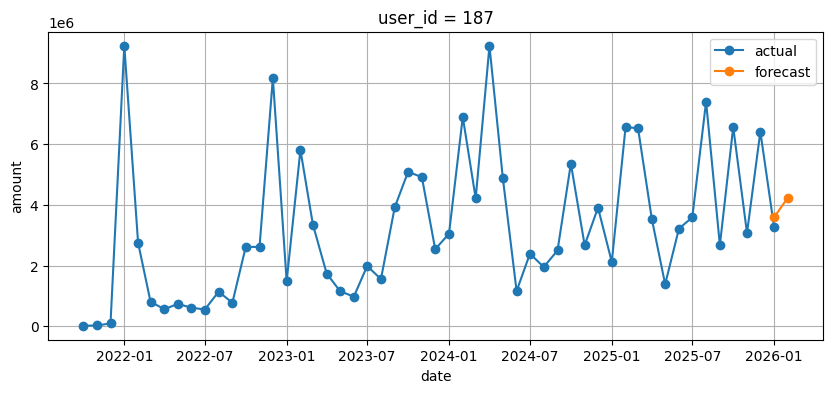

In [ ]:
# нарисуем график исторических данных и прогнозов по заданному user_id

uid = 187

# история
hist = (
    actual_monthly_payments
    .loc[(actual_monthly_payments["user_id"] == uid)&
         (actual_monthly_payments["date"] < actual_month)]
    .sort_values("date")
)

# прогнозы
fc = (
    forecasts_catboost_monthly
    .loc[forecasts_catboost_monthly["user_id"] == uid]
    .sort_values("date")
)

hist = hist.copy()
fc = fc.copy()

hist["date"] = hist["date"].dt.to_timestamp()
fc["date"] = fc["date"].dt.to_timestamp()

plt.figure(figsize=(10, 4))

plt.plot(
    hist["date"],
    hist["month_payments_sum"],
    label="actual",
    marker="o"
)

plt.plot(
    fc["date"],
    fc["forecast_amount"],
    label="forecast",
    marker="o"
)

plt.title(f"user_id = {uid}")
plt.xlabel("date")
plt.ylabel("amount")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# считаем метрики
def calc_metrics(g):
    user_id = g.name
    
    y_true = g["month_payments_sum"].values
    y_pred = g["forecast_amount"].values

    # история для MASE
    y_train = (
        actual_monthly_payments
        .loc[actual_monthly_payments["user_id"] == user_id]
        .sort_values("date")["month_payments_sum"]
        .values
    )

    return pd.Series({
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mase": mase(y_true, y_pred, y_train)
    })


df_metrics = (
    df
    .groupby("user_id")
    .apply(calc_metrics)
    .reset_index()
)


In [9]:
df_metrics.to_csv('metrics_real_forecast.csv', index=False)

df_metrics

,user_id,rmse,mase
0,41,374269.49,0.431488
1,65,6342751.32,1.624179
2,106,97092.96,0.242590
3,114,29845.77,0.009421
4,123,1145003.54,0.674599
5,138,422488.50,1.316415
6,172,161014.86,0.227466
7,176,724656.31,0.952830
8,185,812311.81,0.982598
9,187,335968.14,0.139909
